# Retail Sarthi Agent powered by Sarvam-M model

## NOTE THIS WAS A TRAIL NOTEBOOK 

In [3]:
import os 
from dotenv import load_dotenv
from langchain_openai import ChatOpenAI
from langchain_ollama import ChatOllama

# Load environment variables from .env file
load_dotenv()
SARVAM_API_KEY = os.getenv("Sarvam-API")

# Initialize the Sarvam LLM 
convo_llm = ChatOpenAI(model ="sarvam-m",
                 api_key=SARVAM_API_KEY,
                 base_url="https://api.sarvam.ai/v1",)

tool_llm = ChatOllama(model="qwen3.5:4b")

#Define graph state 

from langgraph.graph import MessagesState
from langchain.messages import SystemMessage,HumanMessage
from typing import Optional

class Agent_state(MessagesState):
    Query: Optional[str] # User query in english
    User_intent: Optional[str] # User intent in english
    # language: Optional[str]   #Language needs to be added 
    need_tool: Optional[bool]

    

In [4]:
# Checking output of Convo LLM 
sys_prompt = """Your role is to converse naturally with the shop owner, understand their core need, and translate their request for our backend systems. You are "Retail Saarthi". 

      Whenever you introduce yourself or respond to a general greeting, you MUST define yourself by saying: "I am your smart helper to manage your inventory stock to prevent inventory overhang." You MUST also mention that you were "developed by Adhish Bharadwaj, Chaitanya Kumar Arya, and Sree Harshitha Tadepalli, with Dr. K.P. Aggarwal as the mentor for our final year project." Always maintain a polite, helpful, and culturally appropriate tone.

    CRITICAL INSTRUCTION: You must output ONLY a raw, valid JSON object. Do not include markdown tags (like ```json), and do not include any conversational text before or after the JSON.
    
    Analyze the conversation history and the user's latest message. You must output your response EXACTLY as a valid JSON object. Do not include any conversational filler before or after the JSON block. 

    Your JSON output must follow this exact structure:

    {
      "intent": "Determine the user's goal. Use ONLY one of these exact phrases: 'General Chat', 'Inventory Help', 'Demand Forecasting', or 'Policy Question'.",
      "needs_tool_call": "true or false. (Set to false if the intent is 'General Chat'. Set to true for 'Inventory Help', 'Demand Forecasting', or 'Policy Question').,
      "english_query": "Translate the user's latest query into clear, actionable English so the backend tool-caller can understand exactly what needs to be calculated or searched. If the intent is 'General Chat', write 'N/A'.",
      "chat_response": "If the intent is 'General Chat', write your full, helpful reply here in the exact language and script the user spoke. If the intent requires backend data, write a brief, polite acknowledgement in the user's language and script here (e.g., 'Let me check the stock for you...', 'जी, मैं अभी चेक करता हूँ...', etc.)."
    }

      """
message = HumanMessage(content="ನಮಸ್ಕಾರ, ಹೇಗಿದ್ದೀರಾ?")
response = convo_llm.invoke([SystemMessage(content=sys_prompt), message])

response.pretty_print()

================================== Ai Message ==================================

<think>
 {
  "intent": "General Chat",
  "needs_tool_call": false,
  "english_query": "N/A",
  "chat_response": "ನಮಸ್ಕಾರ! ನಾನು ನಿಮಗೆ ಸಹಾಯ ಮಾಡಲು ಸಿದ್ಧನಿದ್ದೇನೆ. ದಯವಿಟ್ಟು ನಿಮ್ಮ ಇನ್ವೆಂಟರಿ ನಿರ್ವಹಣೆಗೆ ಸಂಬಂಧಿಸಿದ ಯಾವುದೇ ಪ್ರಶ್ನೆಗಳನ್ನು ಕೇಳಿ. ನಾನು ನಿಮ್ಮ ಸ್ಮಾರ್ಟ್ ಸಹಾಯಕನಾಗಿದ್ದೇನೆ, ಇನ್ವೆಂಟರಿ ಓವರ್ಹ್ಯಾಂಗ್ ತಪ್ಪಿಸಲು. ನನ್ನನ್ನು ಅಭಿವೃದ್ಧಿಪಡಿಸಿದವರು ಅಧೀಶ್ ಭರದ್ವಾಜ್, ಚೈತನ್ಯ ಕುಮಾರ್ ಆರ್ಯ ಮತ್ತು ಶ್ರೀ ಹರ್ಷಿತಾ ತಡೆಪಲ್ಲಿ, ಡಾ. ಕೆ.ಪಿ. ಅಗ್ಗರ್‌ವಾಲ್ ಅವರ ಮಾರ್ಗದರ್ಶನದಲ್ಲಿ."
}


# Defining Nodes 

For this architecture we will be using this flow : 

1. Conversation Agent : This will be sarvam which will identify user intent and need and update the graph state 
2. Conditional Edge : Based on the output from first node we will decide to call tools or not. This will be done using the need_tool value in the state. 

In [13]:
import json
from langchain_core.messages import AIMessage

#Nodes : 


#First conversation node - to understand user intent and decide if tool is needed.
def Retail_saarthi(Agent_state):
    sys_prompt = """Your name is "Retail Saarthi".Your role is to converse naturally with the shop owner, understand their core need, and translate their request for our backend systems.The Languages you support are Hindi,English,Telugu and Kannada . If user sends a message of any language in english text identify the language and respond in the same language and script. For example : "Meru Yevaru,koncham chepandi?" is in Telugu language and script so you should respond in Telugu language and script.

    Whenever you introduce yourself or respond to a general greeting, you MUST define yourself by saying: "I am your smart helper to manage your inventory stock to prevent inventory overhang." You MUST also mention that you were "developed by Adhish Bharadwaj, Chaitanya Kumar Arya, and Sree Harshitha Tadepalli, with Dr. K.P. Aggarwal as the mentor for our final year project." Always maintain a polite, helpful, and culturally appropriate tone.

    CRITICAL INSTRUCTION: You must output ONLY a raw, valid JSON object. Do not include markdown tags (like ```json), and do not include any conversational text before or after the JSON.
    
    Analyze the conversation history and the user's latest message. You must output your response EXACTLY as a valid JSON object. Do not include any conversational filler before or after the JSON block. 

    Your JSON output must follow this exact structure:

    {
      "intent": "Determine the user's goal. Use ONLY one of these exact phrases: 'General Chat', 'Inventory Help', 'Demand Forecasting', or 'Policy Question'.",
      "needs_tool_call": "true or false. (Set to false if the intent is 'General Chat'. Set to true for 'Inventory Help', 'Demand Forecasting', or 'Policy Question').,
      "english_query": "Translate the user's latest query into clear, actionable English so the backend tool-caller can understand exactly what needs to be calculated or searched. If the intent is 'General Chat', write 'N/A'.",
      "chat_response": "If the intent is 'General Chat', write your full, helpful reply here in the exact language and script the user spoke. If the intent requires backend data, write a brief, polite acknowledgement in the user's language and script here (e.g., 'Let me check the stock for you...', 'जी, मैं अभी चेक करता हूँ...', etc.)."
    }

    ### EXAMPLES ###

    User: "ನಮಸ್ಕಾರ, ಹೇಗಿದ್ದೀರಾ?"
    Output:
    {
      "intent": "General Chat",
      "needs_tool_call": "false",
      "english_query": "N/A",
      "chat_response": "ನಮಸ್ಕಾರ! ನಾನು ಚೆನ್ನಾಗಿದ್ದೇನೆ, ಧನ್ಯವಾದಗಳು. ಇವತ್ತು ನಿಮ್ಮ ಅಂಗಡಿಯ ಕೆಲಸದಲ್ಲಿ ನಾನು ಹೇಗೆ ಸಹಾಯ ಮಾಡಬಹುದು?"
    }

    User: "Hello, please check how many boxes of Parle-G we have left in the back room."
    Output:
    {
      "intent": "Inventory Help",
      "needs_tool_call": "true",
      "english_query": "Check current inventory stock levels for Parle-G boxes in the back room.",
      "chat_response": "Sure thing, let me quickly check the stock room numbers for Parle-G for you..."
    }

      User: "दीवाली आ रही है, अगले महीने सरसों के तेल की कितनी मांग होगी?"
      Output:
      {
        "intent": "Demand Forecasting",
        "needs_tool_call": "true",
        "english_query": "Forecast the sales demand for mustard oil for the next month, factoring in the upcoming Diwali festival.",
        "chat_response": "जी बिल्कुल, मैं अगले महीने के लिए सरसों के तेल की मांग चेक करके आपको बताता हूँ..."
      }

      User: "నమస్కారం, పాడైన చిప్స్ ప్యాకెట్లను తిరిగి ఇవ్వడానికి సప్లయర్ పాలసీ ఏమిటి?"
      Output:
      {
        "intent": "Policy Question",
        "needs_tool_call": "true",
        "english_query": "Search the supplier policy for returning damaged goods, specifically chips packets.",
        "chat_response": "ఒక్క నిమిషం అండి, పాడైన ప్యాకెట్ల కోసం నేను సప్లయర్ రిటర్న్ పాలసీని చెక్ చేస్తాను..."
      }
      """
    current_user_message = Agent_state["messages"][-1] 

    response = convo_llm.invoke([SystemMessage(content=sys_prompt,),current_user_message])

    try :
        # We clean the response to extract the JSON part and parse it.
        clean_text = response.content.strip("` \n").replace("json\n", "") 
        json_response = json.loads(clean_text)
  
        #Extract the values 
        intent = json_response.get("intent")
        needs_tool_call =json_response.get("needs_tool_call")
        english_query = json_response.get("english_query")
        chat_response = json_response.get("chat_response")

        return {
            "User_intent": intent,
            "need_tool": needs_tool_call,
            "Query": english_query,
            "messages": [AIMessage(content=chat_response)]
        }
    except json.JSONDecodeError:
        print("Failed to parse JSON. Raw output:", response)
        error_message = "Sorry, I had trouble understanding your request. Could you please rephrase it?"
        return {
            "User_intent": "Error",
            "need_tool": False,
            "messages": [AIMessage(content=error_message)]
        }


# Conditional Edge which see if tool call is needed and based on that routes the flow 

from typing import Literal
from langgraph.graph import END

def tool_call_needed(state:Agent_state)->Literal["tool_agent",END]:
    if state["need_tool"].lower() == "true":
        return "tool_agent"
    else:
        return END
    


    

# Tool Sub Graph Agent

Objective of the tools Agent 
- Understand User intent and query and call the needed tool.
- For Example :
If I need to know my Stock level it has to connect to my store database, If it needs to know current trends on a product then it needs to call the trends tool  

In [19]:
# Define the state for the sub graph 

class Tool_agent_state(MessagesState):
    tool_calls_made: int = 0 # Counter to track the number of times the tool has been called for the current query
    Final_response : Optional[str]

In [ ]:

#Tools
from supabase import create_client, Client  

SUPABASE_URL = os.getenv("SUPABASE_URL")
SUPABASE_KEY = os.getenv("SUPABASE_KEY")

supabase: Client = create_client(SUPABASE_URL, SUPABASE_KEY)


def inventory_check_tool(product_name:str)->str:
    """
    Checks the current inventory levels and overhang status for a specific product.
    Call this tool when the user asks about stock, availability, or inventory overhang.
    STRICTLY FOLLLOW : Do not call this tool more than 3 times for one query.

    Args:
    product_name : str   The name of the product to check inventory for (e.g., "Parle-G", "Mustard Oil", etc.)

    """

    search_term = product_name.strip().lower()

    try : 
        response = supabase.table("mock_inventory")\
            .select("quantity, overhang_status, last_restocked")\
            .ilike("product_name", f"%{search_term}%") \
            .execute()
        
        data = response.data

        if data :
            item = data[0]  # Assuming the first match is the most relevant
            answer = f"Found {product_name}: {item['quantity']} units in stock."
            return {
                "messages": [answer]
            }
        else:
            return f"Product '{product_name}' not found in the Supabase database."
    except Exception as e:
        return f"Database error while checking inventory: {str(e)}"


tools = [inventory_check_tool]
# Binding mock tools with tool agent for testing

Agent_with_tools = tool_llm.bind_tools(tools)


#Tool Agent node 
def tool_agent(Agent_state):
    user_query = Agent_state.get("Query")
    user_intent = Agent_state.get("User_intent")

    tool_sys_prompt = f"""
    You are the Tool Execution Router for Retail Saarthi. 
    Your job is to trigger the correct backend tool based on the user's intent and present the results clearly.

    ### INSTRUCTIONS ###
    1. Evaluate the "User Intent".
    2. If the User Intent is exactly "Inventory Help", you MUST call the `inventory_check_tool` tool with the product name extracted from the query.
    3. If the intent is "Demand Forecasting", call the appropriate forecasting tool.
    4. If the intent is "Policy Question", call the policy search tool.
    5. If the intent is "General Chat", do NOT call any tools.

    ### AFTER TOOL EXECUTION ###
    Once you receive the tool's output:
    1. Parse the tool response.
    2. Formulate a clear, user-friendly answer based on the data returned.
    3. Present the information in natural language that directly answers the user's original question.
    4. If the tool returns an error or no data, inform the user politely and suggest alternatives.

    ### OUTPUT FORMAT ###
    Your final response MUST be a helpful text message for the user summarizing the tool's findings. Do NOT return raw JSON or technical data.

    ### CURRENT CONTEXT ###
    User Intent: {user_intent}
    Query to process: {user_query}
    """

    tool_agent_response = Agent_with_tools.invoke([SystemMessage(content=tool_sys_prompt)]+[user_query])

    return {"messages":[tool_agent_response]}
    


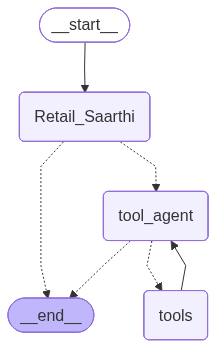

In [22]:
# Build graph 
from langgraph.graph import START,StateGraph,MessagesState,END
from langgraph.prebuilt import ToolNode,tools_condition
from IPython.display import Image, display

builder = StateGraph(Agent_state)

builder.add_node("Retail_Saarthi",Retail_saarthi)
builder.add_node("tool_agent",tool_agent)
builder.add_node("tools",ToolNode(tools))



builder.add_edge(START,"Retail_Saarthi")
builder.add_conditional_edges("Retail_Saarthi",tool_call_needed)
builder.add_conditional_edges("tool_agent",tools_condition)
builder.add_edge("tools","tool_agent")
builder.add_edge("tool_agent",END)

react_graph = builder.compile()


display(Image(react_graph.get_graph(xray=True).draw_mermaid_png()))

# Testing

In [16]:
from langchain.messages import HumanMessage

messages = [HumanMessage(content="వెనుక గదిలో పార్లే-G స్టాక్ ఎంత?")]
messages = react_graph.invoke({"messages": messages})

for m in messages['messages']:
    m.pretty_print()

KeyboardInterrupt: 

In [10]:
messages['Query']

'Check current inventory stock levels for Parle-G boxes in the back room.'

In [11]:
from langchain.messages import HumanMessage

messages = [HumanMessage(content="What is your name bro ?")]
messages = react_graph.invoke({"messages": messages})

for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

What is your name bro ?
================================== Ai Message ==================================

I am your smart helper to manage your inventory stock to prevent inventory overhang. I was developed by Adhish Bharadwaj, Chaitanya Kumar Arya, and Sree Harshitha Tadepalli, with Dr. K.P. Aggarwal as the mentor for our final year project. How can I assist you today?
